In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
ftsz = 12
plt.rcParams["font.family"] = "Serif"
plt.rc('xtick', labelsize=ftsz)
plt.rc('ytick', labelsize=ftsz)

# Au-Ag system: solid solution and atom swaps

Run at 900 C, pure NVT. The system is initialised with two blocks of Ag and Au in contact, with a vacancy concentration of 1% to aid solid solution. The two slowly start mixing.


In [66]:
data_NVTonly = np.loadtxt('AgAu/AgAu_nvt_900C_1pcv.dat', skiprows=1)
data_NVT_atomswap = np.loadtxt('AgAu/AgAu_nvt_900C_atomswap_1pcv.dat', skiprows=1)

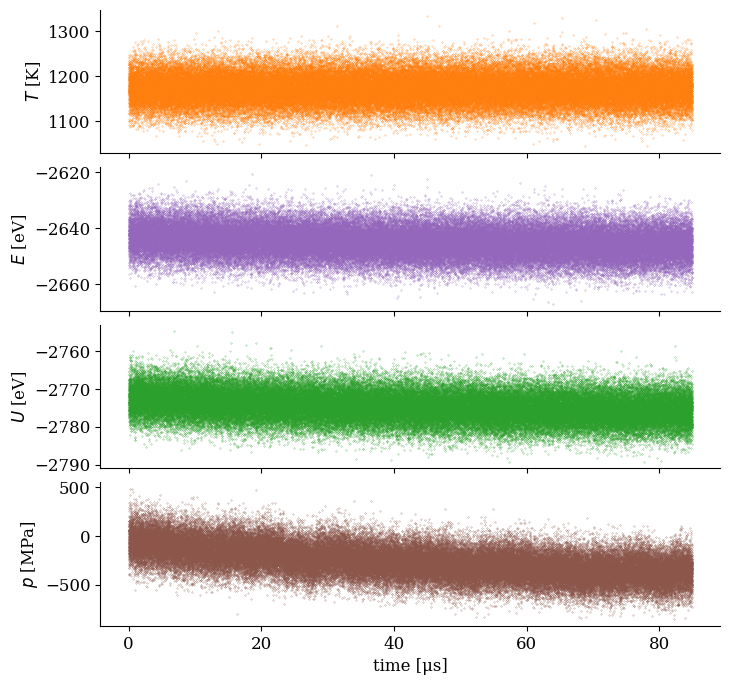

In [67]:
# Check the time evolution

fig, ax = plt.subplots(4, 1, figsize=(8, 8), sharex=True, gridspec_kw={"hspace": 0.1})

# Each entry: (column index in data, scale_factor, ylabel)
channels = [
    (1, 1,          r"$T$ [K]"),
    (4, 1,  r"$E$ [eV]"),
    (2, 1,  r"$U$ [eV]"),
    (5, 0.1,   r"$p$ [MPa]"),
]

t = (data_NVTonly[:, 0] - data_NVTonly[0, 0])*1e-6 # ps to us
for axis, (col, scale, label) in zip(ax, channels):
    axis.plot(t, scale * data_NVTonly[:, col], 'o', markersize=0.2, color=f'C{col}')
    
for axis, (_, _, label) in zip(ax, channels):
    axis.set_ylabel(label, fontsize=ftsz)
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)
ax[3].set_xlabel("time [μs]", fontsize=ftsz)

plt.show()

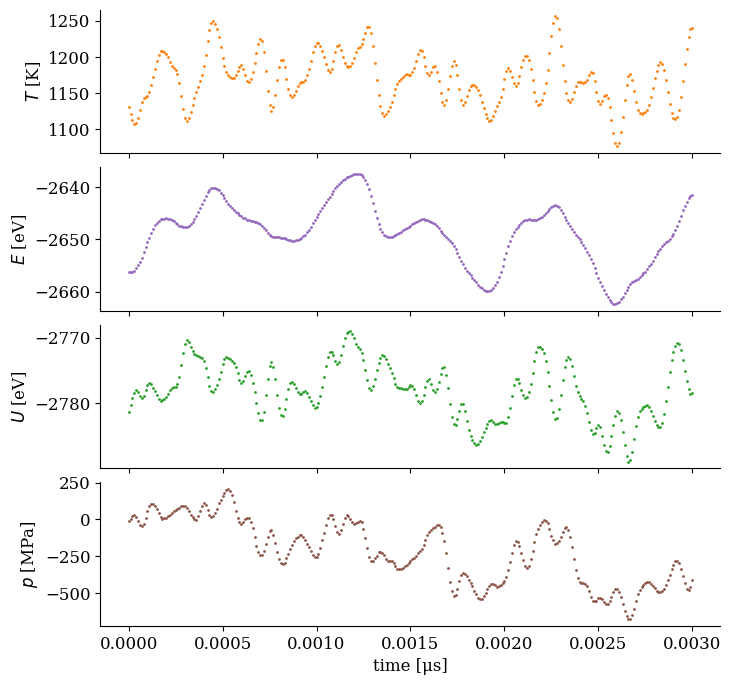

In [68]:
# Check the time evolution

fig, ax = plt.subplots(4, 1, figsize=(8, 8), sharex=True, gridspec_kw={"hspace": 0.1})

# Each entry: (column index in data, scale_factor, ylabel)
channels = [
    (1, 1,          r"$T$ [K]"),
    (4, 1,  r"$E$ [eV]"),
    (2, 1,  r"$U$ [eV]"),
    (5, 0.1,   r"$p$ [MPa]"),
]

t = (data_NVT_atomswap[:, 0] - data_NVT_atomswap[0, 0])*1e-6 # ps to us
for axis, (col, scale, label) in zip(ax, channels):
    axis.plot(t, scale * data_NVT_atomswap[:, col], 'o', markersize=1., color=f'C{col}')
    
for axis, (_, _, label) in zip(ax, channels):
    axis.set_ylabel(label, fontsize=ftsz)
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)
ax[3].set_xlabel("time [μs]", fontsize=ftsz)

plt.show()

## Coordination analysis

Let's check with Ovito. We expect the cross-correlation to rise in both cases. But how fast with increasing timestep?

# Grand Canonical Monte Carlo: Adsorption example with Lennard-Jones




In [102]:
data_T0_5_eps12_0_5_eq = np.loadtxt('Adsorption_GCMC/adsorption_mu_-2_T_0.5_eps12_0.5_equil.dat')
data_T0_5_eps12_0_5_run = np.loadtxt('Adsorption_GCMC/adsorption_mu_-2_T_0.5_eps12_0.5_run.dat')
data_T1_0_eps12_0_5_eq = np.loadtxt('Adsorption_GCMC/adsorption_mu_-2_T_1_eps12_0.5_equil.dat')
data_T1_0_eps12_0_5_run = np.loadtxt('Adsorption_GCMC/adsorption_mu_-2_T_1_eps12_0.5_run.dat')
data_T0_5_eps12_2_0_eq = np.loadtxt('Adsorption_GCMC/adsorption_mu_-2_T_0.5_eps12_2_equil.dat')
data_T0_5_eps12_2_0_run = np.loadtxt('Adsorption_GCMC/adsorption_mu_-2_T_0.5_eps12_2_run.dat')
data_T1_0_eps12_2_0_eq = np.loadtxt('Adsorption_GCMC/adsorption_mu_-2_T_1_eps12_2_equil.dat')
data_T1_0_eps12_2_0_run = np.loadtxt('Adsorption_GCMC/adsorption_mu_-2_T_1_eps12_2_run.dat')

step_eq = np.arange(data_T0_5_eps12_0_5_eq.shape[0])
step_run = np.arange(data_T0_5_eps12_0_5_eq.shape[0], data_T0_5_eps12_0_5_eq.shape[0]+data_T0_5_eps12_0_5_run.shape[0])


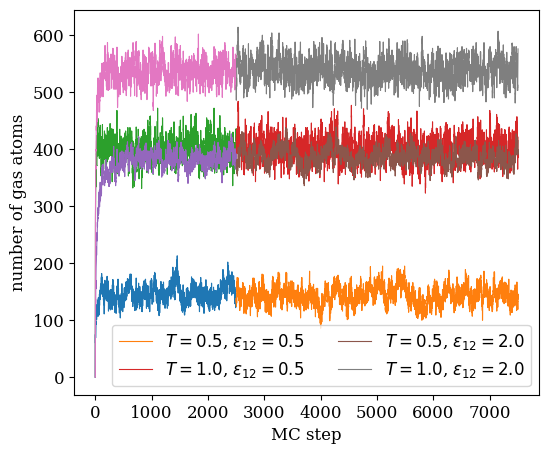

In [55]:
plt.figure(figsize=(6, 5))

plt.plot(step_eq, data_T0_5_eps12_0_5_eq[:,1], linewidth=0.8)
plt.plot(step_run, data_T0_5_eps12_0_5_run[:,1], linewidth=0.8, label=r"$T=0.5$, $\epsilon_{12}=0.5$")

plt.plot(step_eq, data_T1_0_eps12_0_5_eq[:,1], linewidth=0.8)
plt.plot(step_run, data_T1_0_eps12_0_5_run[:,1], linewidth=0.8, label=r"$T=1.0$, $\epsilon_{12}=0.5$")

plt.plot(step_eq, data_T0_5_eps12_2_0_eq[:,1], linewidth=0.8)
plt.plot(step_run, data_T0_5_eps12_2_0_run[:,1], linewidth=0.8, label=r"$T=0.5$, $\epsilon_{12}=2.0$")

plt.plot(step_eq, data_T1_0_eps12_2_0_eq[:,1], linewidth=0.8)
plt.plot(step_run, data_T1_0_eps12_2_0_run[:,1], linewidth=0.8, label=r"$T=1.0$, $\epsilon_{12}=2.0$")

plt.xlabel('MC step', fontsize=ftsz)
plt.ylabel('number of gas atoms', fontsize=ftsz)
plt.legend(fontsize=ftsz, ncols=2)

plt.show()

In [103]:
print("acceptance rate of insertions and deletions for T = 0.5 and eps12 = 0.5: ", data_T0_5_eps12_0_5_run[-1, 2], " and ", data_T0_5_eps12_0_5_run[-1, 3])
print("acceptance rate of insertions and deletions for T = 0.5 and eps12 = 2.0: ", data_T0_5_eps12_2_0_run[-1, 2], " and ", data_T0_5_eps12_2_0_run[-1, 3])
print("acceptance rate of insertions and deletions for T = 1.0 and eps12 = 0.5: ", data_T1_0_eps12_0_5_run[-1, 2], " and ", data_T1_0_eps12_0_5_run[-1, 3])
print("acceptance rate of insertions and deletions for T = 1.0 and eps12 = 2.0: ", data_T1_0_eps12_2_0_run[-1, 2], " and ", data_T1_0_eps12_2_0_run[-1, 3])


acceptance rate of insertions and deletions for T = 0.5 and eps12 = 0.5:  0.334934245520874  and  0.335308012607881
acceptance rate of insertions and deletions for T = 0.5 and eps12 = 2.0:  0.135541529733616  and  0.13550942989401
acceptance rate of insertions and deletions for T = 1.0 and eps12 = 0.5:  0.451079882870763  and  0.451457046455957
acceptance rate of insertions and deletions for T = 1.0 and eps12 = 2.0:  0.384900614106228  and  0.385106755430963


## Gas density profiles

Plot the concentration profile orthogonal to the two slabs, which should show the adsorption profile.

In [105]:
# load the files where the gas atoms were binned into slabs parallel to the surface.
# Rows have the bin index, z coordinate, number of gas atoms and density as number/total.

profile_T1_0_eps12_0_5 = np.loadtxt('Adsorption_GCMC/density_profile_mu_-2_T_1_eps12_0.5.dat', skiprows=4)
profile_T1_0_eps12_2_0 = np.loadtxt('Adsorption_GCMC/density_profile_mu_-2_T_1_eps12_2.dat', skiprows=4)
profile_T0_5_eps12_0_5 = np.loadtxt('Adsorption_GCMC/density_profile_mu_-2_T_0.5_eps12_0.5.dat', skiprows=4)
profile_T0_5_eps12_2_0 = np.loadtxt('Adsorption_GCMC/density_profile_mu_-2_T_0.5_eps12_2.dat', skiprows=4)

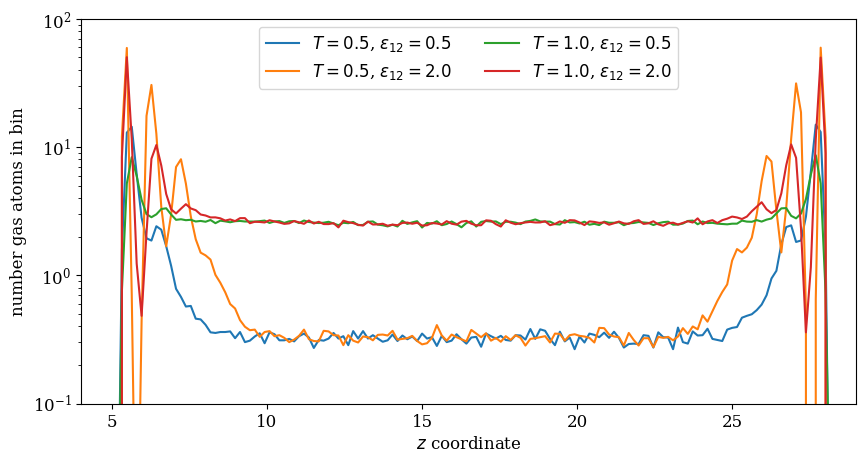

In [106]:
plt.figure(figsize=(10, 5))
plt.plot(profile_T0_5_eps12_0_5[:, 1], profile_T0_5_eps12_0_5[:, 2], label=r"$T=0.5$, $\epsilon_{12}=0.5$")
plt.plot(profile_T0_5_eps12_2_0[:, 1], profile_T0_5_eps12_2_0[:, 2], label=r"$T=0.5$, $\epsilon_{12}=2.0$")
plt.plot(profile_T1_0_eps12_0_5[:, 1], profile_T1_0_eps12_0_5[:, 2], label=r"$T=1.0$, $\epsilon_{12}=0.5$")
plt.plot(profile_T1_0_eps12_2_0[:, 1], profile_T1_0_eps12_2_0[:, 2], label=r"$T=1.0$, $\epsilon_{12}=2.0$")
plt.xlim(4, 29)
plt.ylim(1e-1, 1e2)
plt.xlabel(r'$z$ coordinate', fontsize=ftsz)
plt.ylabel('number gas atoms in bin', fontsize=ftsz)
plt.legend(fontsize=ftsz, ncols=2)

plt.yscale('log')